In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Load the dataset
file_path = "/Users/benvarvill/Documents/APS Contacted Uncontacted.xlsx"
df = pd.read_excel(file_path)

# Define categorical and numerical columns
categorical_cols = ['Type', 'Source', 'Contacted?', 'Tracker Theme', 'Country']
numerical_cols = []  # No numerical columns were detected apart from 'Result'

# Convert categorical columns to string type
df[categorical_cols] = df[categorical_cols].astype(str)

# Target Encode 'Country' (High Cardinality)
country_means = df.groupby('Country')['Result'].mean()
df['Country_encoded'] = df['Country'].map(country_means)

# One-Hot Encode other categorical variables
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
X_categorical = encoder.fit_transform(df[['Type', 'Source', 'Contacted?', 'Tracker Theme']])

# Combine processed categorical data
X_processed = np.hstack((X_categorical, df[['Country_encoded']].values))

# Define target variable
y = df['Result'].astype(int)

# Train-Test Split (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Logistic Regression Model Accuracy: 0.66
              precision    recall  f1-score   support

           0       0.94      0.68      0.79       314
           1       0.14      0.53      0.22        30

    accuracy                           0.66       344
   macro avg       0.54      0.60      0.50       344
weighted avg       0.87      0.66      0.74       344



In [38]:
# Calculate success rate per category
categorical_cols = ['Type', 'Source', 'Contacted?', 'Tracker Theme', 'Country']

for col in categorical_cols:
    success_rates = df.groupby(col)['Result'].mean().sort_values(ascending=False)
    print(f"Success Rate by {col}:\n{success_rates}\n")

Success Rate by Type:
Type
(NP) Nonprofit                 0.181818
(SP) Small Private             0.179487
(BP) Big Private               0.145000
(RES) Research Institution     0.104895
(GOV) Government               0.089552
(GP) Government Partnership    0.076923
(MP) Medium Private            0.063241
(BU) Big University            0.063202
(AP) Academic Partnership      0.062500
(MU) Medium University         0.049327
(CON) Consortium               0.000000
(FND) Foundation               0.000000
(PP) Private Partnership       0.000000
(SU) Small University          0.000000
Name: Result, dtype: float64

Success Rate by Source:
Source
Exhibitors' List    0.166667
KWS                 0.125245
Website             0.125000
Unknown             0.084906
Attendee List       0.055556
Inside Out          0.051724
Chatbot             0.051282
Funding             0.050847
News                0.046832
Other               0.044521
Speakers' List      0.000000
Name: Result, dtype: float64

Suc

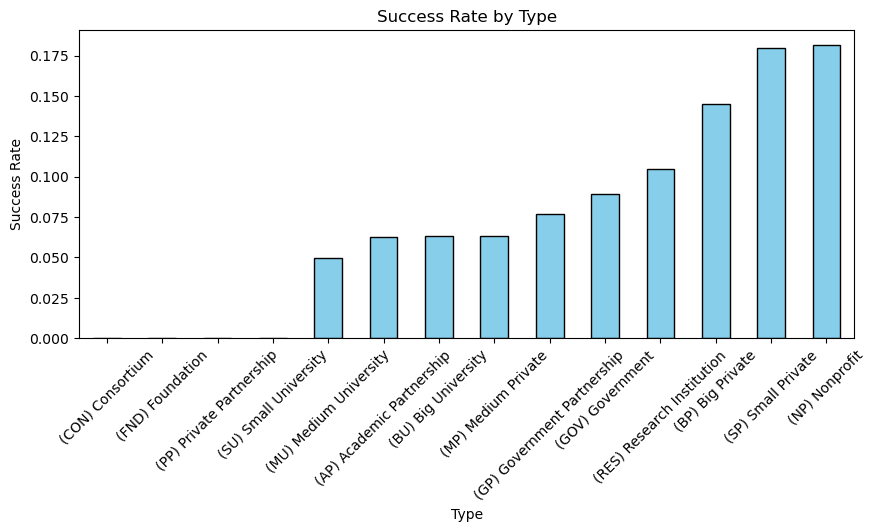

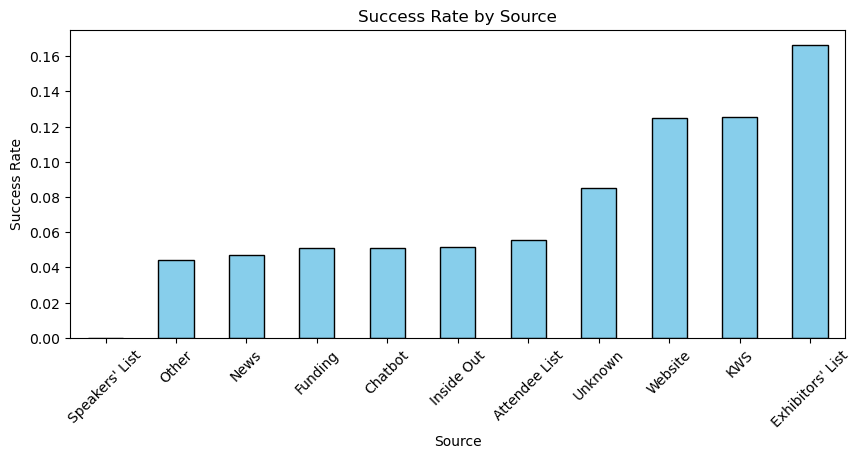

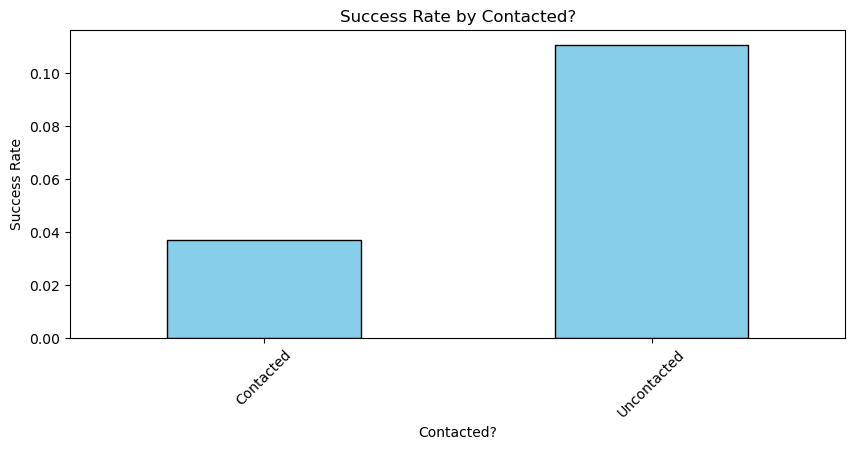

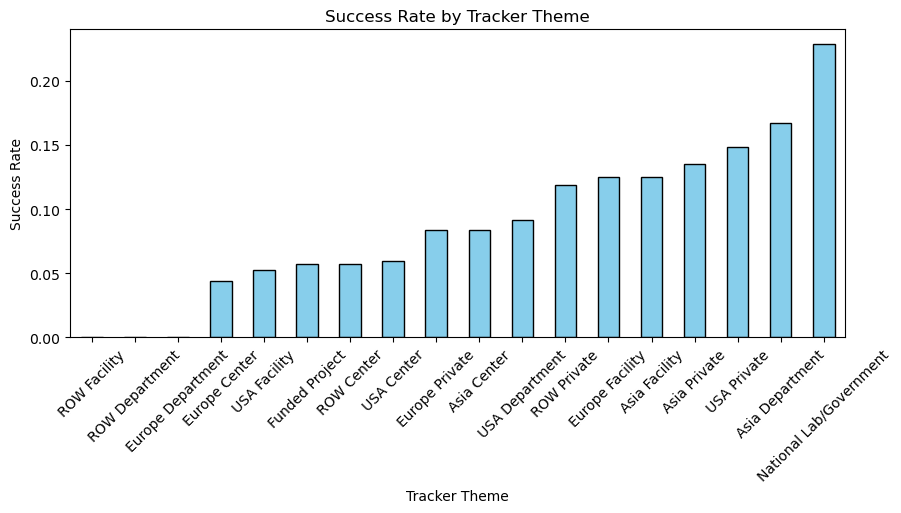

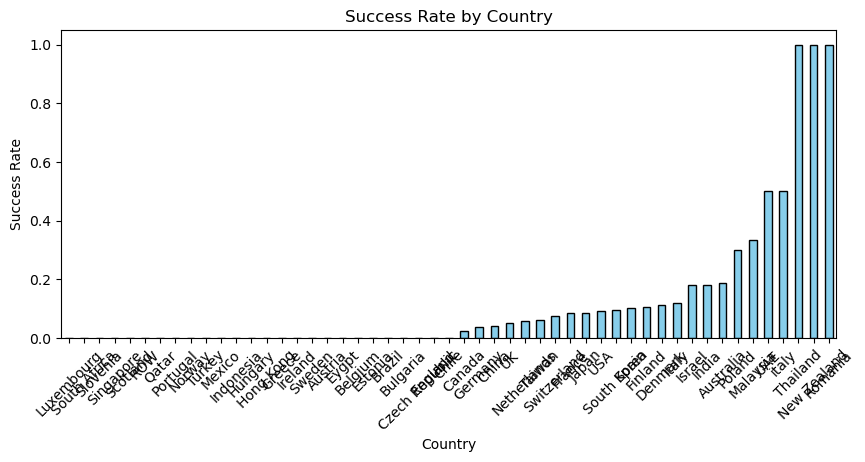

In [40]:
import matplotlib.pyplot as plt

for col in categorical_cols:
    success_rates = df.groupby(col)['Result'].mean().sort_values()
    
    plt.figure(figsize=(10, 4))
    success_rates.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Success Rate by {col}')
    plt.ylabel('Success Rate')
    plt.xticks(rotation=45)
    plt.show()

In [42]:
# Get feature importance from logistic regression coefficients
feature_names = encoder.get_feature_names_out(input_features=['Type', 'Source', 'Contacted?', 'Tracker Theme'])
feature_names = list(feature_names) + ['Country_encoded']

importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_[0]})
importance = importance.sort_values(by='Coefficient', ascending=False)

print("Top Positive Influences on Success:")
print(importance.head(10))

print("\nTop Negative Influences on Success:")
print(importance.tail(10))

Top Positive Influences on Success:
                                  Feature  Coefficient
41                        Country_encoded     4.816013
40              Tracker Theme_USA Private     1.439616
8                     Type_(NP) Nonprofit     1.403869
14                Source_Exhibitors' List     1.323303
21                         Source_Unknown     1.144506
38           Tracker Theme_USA Department     1.133226
23                 Contacted?_Uncontacted     1.097770
32  Tracker Theme_National Lab/Government     1.033279
17                             Source_KWS     0.829306
26             Tracker Theme_Asia Private     0.822234

Top Negative Influences on Success:
                            Feature  Coefficient
34     Tracker Theme_ROW Department    -0.356488
22                   Source_Website    -0.384142
7       Type_(MU) Medium University    -0.472096
27      Tracker Theme_Europe Center    -0.490610
25      Tracker Theme_Asia Facility    -0.518391
33         Tracker Theme_ROW